# Phase1-FeatureExtraction

 Install and Import Libraries

In [1]:
!pip install transformers librosa --quiet

import os
import random
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data   import DataLoader, TensorDataset
from transformers import (
    Wav2Vec2Model,
    Wav2Vec2Processor,
    HubertModel,
    Wav2Vec2FeatureExtractor,
)
from tqdm                import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics        import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing  import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

print("All libraries imported successfully")

All libraries imported successfully


Reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Random seed set to {SEED}")

Random seed set to 42


Configuration Block

In [3]:
# ── dataset identity ───────────────────────────────────────────────
DATASET_NAME  = "RAVDESS"
NUM_CLASSES   = 8      # neutral, calm, happy, sad, angry, fearful, disgust, surprised

# ── download dataset ───────────────────────────────────────────────
DATASET_PATH  = kagglehub.dataset_download(
    "uwrfkaggler/ravdess-emotional-speech-audio"
)

# ── output ─────────────────────────────────────────────────────────
OUTPUT_PATH   = "/kaggle/working/"

# ── audio ──────────────────────────────────────────────────────────
SAMPLE_RATE   = 16000

# ── models ─────────────────────────────────────────────────────────
HUBERT_MODEL  = "facebook/hubert-large-ls960-ft"
WAV2VEC_MODEL = "facebook/wav2vec2-large-960h"

# ── device ─────────────────────────────────────────────────────────
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# ── output file names ──────────────────────────────────────────────
HUBERT_OUT    = f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_hubert_vectors.npz"
WAV2VEC_OUT   = f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_wav2vec2_vectors.npz"

print(f"Dataset      : {DATASET_NAME}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Dataset path : {DATASET_PATH}")
print(f"Device       : {DEVICE}")

Dataset      : RAVDESS
Num classes  : 8
Dataset path : /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
Device       : cuda


Dataset Loading and Label Preparation

In [4]:
# ── RAVDESS emotion encoding ───────────────────────────────────────

EMOTION_MAP = {
    '01' : 'neutral',
    '02' : 'calm',
    '03' : 'happy',
    '04' : 'sad',
    '05' : 'angry',
    '06' : 'fearful',
    '07' : 'disgust',
    '08' : 'surprised',
}

file_paths = []
labels     = []

for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        if not fname.endswith('.wav'):
            continue
        segments = fname.replace('.wav', '').split('-')
        if len(segments) < 3:
            continue
        code = segments[2]   # emotion at position 2
        if code in EMOTION_MAP:
            file_paths.append(os.path.join(root, fname))
            labels.append(EMOTION_MAP[code])

# ── build dataframe ────────────────────────────────────────────────
df = pd.DataFrame({'path': file_paths, 'emotion': labels})

# ── encode labels as integers ──────────────────────────────────────
LABEL2ID = {label: idx for idx, label in
            enumerate(sorted(df['emotion'].unique()))}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['emotion'].map(LABEL2ID)

print(f"Total samples : {len(df)}")
print(f"Label mapping : {LABEL2ID}")
print(f"\nClass distribution:")
print(df['emotion'].value_counts())

Total samples : 2880
Label mapping : {'angry': 0, 'calm': 1, 'disgust': 2, 'fearful': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprised': 7}

Class distribution:
emotion
surprised    384
disgust      384
fearful      384
sad          384
happy        384
calm         384
angry        384
neutral      192
Name: count, dtype: int64


Audio Preprocessing Verification

In [5]:
def load_audio(path, target_sr=SAMPLE_RATE):
    waveform, sr = librosa.load(path, sr=target_sr, mono=True)
    return waveform

errors = []
for path in df['path'].values:
    try:
        w = load_audio(path)
        assert len(w) > 0
    except Exception as e:
        errors.append((path, str(e)))

if errors:
    print(f"WARNING: {len(errors)} files failed to load")
    for p, err in errors:
        print(f"  {p} → {err}")
else:
    print(f"All {len(df)} files verified — no loading errors")
    print(f"All files resampled to {SAMPLE_RATE} Hz")

All 2880 files verified — no loading errors
All files resampled to 16000 Hz


Model Loading

In [6]:
print("Loading HuBERT large...")
hubert_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL)
hubert_model     = HubertModel.from_pretrained(HUBERT_MODEL)
hubert_model.to(DEVICE)
hubert_model.eval()
for param in hubert_model.parameters():
    param.requires_grad = False
print("HuBERT large loaded and frozen")

print("Loading Wav2Vec2 large...")
wav2vec_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL)
wav2vec_model     = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL)
wav2vec_model.to(DEVICE)
wav2vec_model.eval()
for param in wav2vec_model.parameters():
    param.requires_grad = False
print("Wav2Vec2 large loaded and frozen")
print(f"\nBoth models on device: {DEVICE}")

Loading HuBERT large...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/402 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 large loaded and frozen

Both models on device: cuda


Feature Extraction

In [7]:
def extract_features(model, processor, path, layer_start=0, layer_end=None):
    waveform = load_audio(path)
    inputs   = processor(
        waveform,
        sampling_rate  = SAMPLE_RATE,
        return_tensors = "pt",
        padding        = True,
    )
    input_values = inputs.input_values.to(DEVICE)
    with torch.no_grad():
        outputs = model(input_values, output_hidden_states=True)
    all_layers  = torch.stack(outputs.hidden_states, dim=0).squeeze(1)
    sel_layers  = all_layers[layer_start:layer_end]
    vector      = sel_layers.mean(dim=0).mean(dim=0).cpu().numpy()
    return vector


print("Extracting HuBERT features (all layers)...")
hubert_vectors = []
for path in tqdm(df['path'].values):
    hubert_vectors.append(extract_features(
        hubert_model, hubert_extractor, path))
hubert_vectors = np.array(hubert_vectors)
print(f"HuBERT vectors shape  : {hubert_vectors.shape}")

print("Extracting Wav2Vec2 features (all layers)...")
wav2vec_vectors = []
for path in tqdm(df['path'].values):
    wav2vec_vectors.append(extract_features(
        wav2vec_model, wav2vec_processor, path))
wav2vec_vectors = np.array(wav2vec_vectors)
print(f"Wav2Vec2 vectors shape: {wav2vec_vectors.shape}")

labels_array = df['label'].values
print(f"Labels shape          : {labels_array.shape}")

Extracting HuBERT features (all layers)...


100%|██████████| 2880/2880 [03:04<00:00, 15.64it/s]


HuBERT vectors shape  : (2880, 1024)
Extracting Wav2Vec2 features (all layers)...


100%|██████████| 2880/2880 [03:06<00:00, 15.42it/s]

Wav2Vec2 vectors shape: (2880, 1024)
Labels shape          : (2880,)


Saving the Extracted Vectors

In [8]:
np.savez(HUBERT_OUT,  vectors=hubert_vectors,  labels=labels_array, id2label=str(ID2LABEL))
np.savez(WAV2VEC_OUT, vectors=wav2vec_vectors, labels=labels_array, id2label=str(ID2LABEL))
print(f"HuBERT vectors saved  → {HUBERT_OUT}")
print(f"Wav2Vec2 vectors saved → {WAV2VEC_OUT}")

HuBERT vectors saved  → /kaggle/working/ser_ravdess_hubert_vectors.npz
Wav2Vec2 vectors saved → /kaggle/working/ser_ravdess_wav2vec2_vectors.npz


 Verification

In [9]:
hubert_check  = np.load(HUBERT_OUT,  allow_pickle=True)
wav2vec_check = np.load(WAV2VEC_OUT, allow_pickle=True)
print("=== HuBERT ===")
print(f"  vectors shape : {hubert_check['vectors'].shape}")
print(f"  labels shape  : {hubert_check['labels'].shape}")
print(f"  unique labels : {np.unique(hubert_check['labels'])}")
print("\n=== Wav2Vec2 ===")
print(f"  vectors shape : {wav2vec_check['vectors'].shape}")
print(f"  labels shape  : {wav2vec_check['labels'].shape}")
print(f"  unique labels : {np.unique(wav2vec_check['labels'])}")
print("\n✓ Phase 1 complete")

=== HuBERT ===
  vectors shape : (2880, 1024)
  labels shape  : (2880,)
  unique labels : [0 1 2 3 4 5 6 7]

=== Wav2Vec2 ===
  vectors shape : (2880, 1024)
  labels shape  : (2880,)
  unique labels : [0 1 2 3 4 5 6 7]

✓ Phase 1 complete


# Phase 2: Classification

configuration

In [10]:
FEATURE_DIM       = 1024
N_FOLDS           = 5
N_EPOCHS          = 500
BATCH_SIZE        = 16
LEARNING_RATE     = 5e-4
HIDDEN_DIM        = 512
DROPOUT           = 0.3
WEIGHT_DECAY      = 1e-4
PATIENCE          = 100
USE_CLASS_WEIGHTS = True
NORMALIZE         = True

print(f"Feature dim  : {FEATURE_DIM}")
print(f"Folds        : {N_FOLDS}")
print(f"Epochs       : {N_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Hidden dim   : {HIDDEN_DIM}")
print(f"Dropout      : {DROPOUT}")
print(f"Weight decay : {WEIGHT_DECAY}")
print(f"Patience     : {PATIENCE}")

Feature dim  : 1024
Folds        : 5
Epochs       : 500
Batch size   : 16
Learning rate: 0.0005
Hidden dim   : 512
Dropout      : 0.3
Weight decay : 0.0001
Patience     : 100


Imports

classification model (two feed-forward layers as in the paper)

In [11]:
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x):
        return self.classifier(x)

print(f"EmotionClassifier: Linear({FEATURE_DIM}→{HIDDEN_DIM}) → BN → ReLU → Dropout → Linear({HIDDEN_DIM}→{NUM_CLASSES})")

EmotionClassifier: Linear(1024→512) → BN → ReLU → Dropout → Linear(512→8)


training and evaluation functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)

def compute_metrics(preds, labels):
    wa = accuracy_score(labels, preds) * 100
    ua = balanced_accuracy_score(labels, preds) * 100
    cm = confusion_matrix(labels, preds)
    return wa, ua, cm

print("Functions defined")

Functions defined


5-fold cross-validation function

In [13]:
def run_kfold(X, y, model_name):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_wa, fold_ua   = [], []
    all_preds, all_labels = [], []
    history = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test  = scaler.transform(X[test_idx])
        y_train = y[train_idx]
        y_test  = y[test_idx]

        if USE_CLASS_WEIGHTS:
            counts  = np.bincount(y_train, minlength=NUM_CLASSES)
            weights = 1.0 / (counts.astype(np.float32) + 1e-6)
            weights = torch.tensor(weights / weights.sum() * NUM_CLASSES).to(DEVICE)
        else:
            weights = None

        train_loader = DataLoader(
            TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                           torch.tensor(y_train, dtype=torch.long)),
            batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(
            TensorDataset(torch.tensor(X_test,  dtype=torch.float32),
                           torch.tensor(y_test,  dtype=torch.long)),
            batch_size=BATCH_SIZE, shuffle=False)

        model = EmotionClassifier(FEATURE_DIM, HIDDEN_DIM, NUM_CLASSES, DROPOUT).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=20, factor=0.5, min_lr=1e-6)

        best_loss, patience_ctr, best_state = float('inf'), 0, None
        fold_losses, fold_was = [], []

        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, train_loader, criterion, optimizer)
            scheduler.step(loss)
            fold_losses.append(loss)
            if (epoch + 1) % 10 == 0:
                p, l = evaluate(model, test_loader)
                fold_was.append(accuracy_score(l, p) * 100)
            if loss < 0.01:
                break
            if loss < best_loss:
                best_loss, patience_ctr = loss, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    break

        model.load_state_dict(best_state)
        preds, labels_fold = evaluate(model, test_loader)
        wa, ua, _          = compute_metrics(preds, labels_fold)
        fold_wa.append(wa)
        fold_ua.append(ua)
        all_preds.extend(preds)
        all_labels.extend(labels_fold)
        history.append({'fold': fold, 'losses': fold_losses,
                        'was': fold_was, 'epochs': len(fold_losses)})
        print(f"  [{model_name}] Fold {fold}/{N_FOLDS} — WA: {wa:.2f}%  UA: {ua:.2f}%  epochs: {len(fold_losses)}  best_loss: {best_loss:.4f}")

    mean_wa, std_wa = np.mean(fold_wa), np.std(fold_wa)
    mean_ua, std_ua = np.mean(fold_ua), np.std(fold_ua)
    agg_cm          = confusion_matrix(all_labels, all_preds)
    print(f"\n  [{model_name}] WA: {mean_wa:.2f} ± {std_wa:.2f}")
    print(f"  [{model_name}] UA: {mean_ua:.2f} ± {std_ua:.2f}")
    return {'model_name': model_name, 'fold_wa': fold_wa, 'fold_ua': fold_ua,
            'mean_wa': mean_wa, 'std_wa': std_wa, 'mean_ua': mean_ua,
            'std_ua': std_ua, 'agg_cm': agg_cm, 'history': history}

print("run_kfold defined")

run_kfold defined


 run 5-fold CV for both models

In [14]:
print("="*55)
print("Running 5-fold CV — HuBERT large")
print("="*55)
results_hubert = run_kfold(hubert_vectors, labels_array, "HuBERT")

print("\n" + "="*55)
print("Running 5-fold CV — Wav2Vec2 large")
print("="*55)
results_wav2vec = run_kfold(wav2vec_vectors, labels_array, "Wav2Vec2")

Running 5-fold CV — HuBERT large
  [HuBERT] Fold 1/5 — WA: 98.26%  UA: 98.38%  epochs: 40  best_loss: 0.0158
  [HuBERT] Fold 2/5 — WA: 98.61%  UA: 98.70%  epochs: 45  best_loss: 0.0114
  [HuBERT] Fold 3/5 — WA: 97.92%  UA: 98.05%  epochs: 49  best_loss: 0.0106
  [HuBERT] Fold 4/5 — WA: 98.26%  UA: 97.71%  epochs: 42  best_loss: 0.0135
  [HuBERT] Fold 5/5 — WA: 98.61%  UA: 98.70%  epochs: 54  best_loss: 0.0107

  [HuBERT] WA: 98.33 ± 0.26
  [HuBERT] UA: 98.31 ± 0.38

Running 5-fold CV — Wav2Vec2 large
  [Wav2Vec2] Fold 1/5 — WA: 98.96%  UA: 99.03%  epochs: 54  best_loss: 0.0110
  [Wav2Vec2] Fold 2/5 — WA: 97.92%  UA: 98.05%  epochs: 38  best_loss: 0.0116
  [Wav2Vec2] Fold 3/5 — WA: 97.40%  UA: 97.55%  epochs: 56  best_loss: 0.0113
  [Wav2Vec2] Fold 4/5 — WA: 97.57%  UA: 97.05%  epochs: 58  best_loss: 0.0112
  [Wav2Vec2] Fold 5/5 — WA: 97.22%  UA: 97.40%  epochs: 54  best_loss: 0.0106

  [Wav2Vec2] WA: 97.81 ± 0.62
  [Wav2Vec2] UA: 97.82 ± 0.68


 results summary table

In [15]:
summary = pd.DataFrame([
    {'Dataset': DATASET_NAME, 'Model': 'HuBERT large',
     'Weighted Accuracy'  : f"{results_hubert['mean_wa']:.2f} ± {results_hubert['std_wa']:.2f}",
     'Unweighted Accuracy': f"{results_hubert['mean_ua']:.2f} ± {results_hubert['std_ua']:.2f}"},
    {'Dataset': DATASET_NAME, 'Model': 'Wav2Vec2 large',
     'Weighted Accuracy'  : f"{results_wav2vec['mean_wa']:.2f} ± {results_wav2vec['std_wa']:.2f}",
     'Unweighted Accuracy': f"{results_wav2vec['mean_ua']:.2f} ± {results_wav2vec['std_ua']:.2f}"},
])
print("\n=== RESULTS — RAVDESS ===")
print(summary.to_string(index=False))
print("\n=== PAPER REFERENCE (Table 1) ===")
print("HuBERT   — WA:  92.82±1.5   UA:  93.78±1.6")
print("Wav2Vec2 — WA:  97.67±1.2   UA:  98.02±1.3")


=== RESULTS — RAVDESS ===
Dataset          Model Weighted Accuracy Unweighted Accuracy
RAVDESS   HuBERT large      98.33 ± 0.26        98.31 ± 0.38
RAVDESS Wav2Vec2 large      97.81 ± 0.62        97.82 ± 0.68

=== PAPER REFERENCE (Table 1) ===
HuBERT   — WA:  92.82±1.5   UA:  93.78±1.6
Wav2Vec2 — WA:  97.67±1.2   UA:  98.02±1.3


 confusion matrices

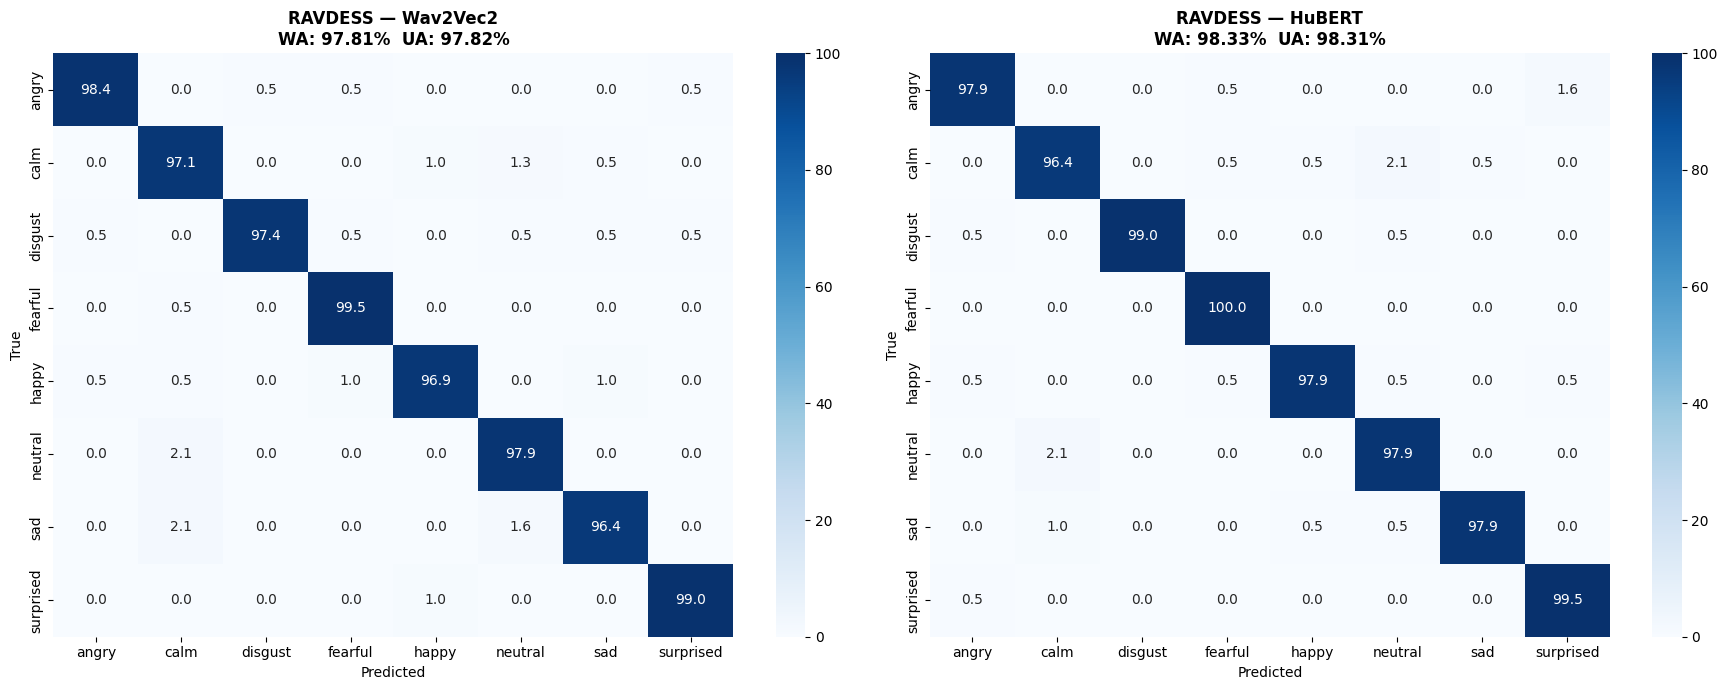

Confusion matrices saved


In [16]:
def plot_confusion_matrix(cm, class_names, title, ax):
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=100)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

class_names = [ID2LABEL[i] for i in range(NUM_CLASSES)]
fig, axes   = plt.subplots(1, 2, figsize=(18, 7))
plot_confusion_matrix(results_wav2vec['agg_cm'], class_names,
    f"RAVDESS — Wav2Vec2\nWA: {results_wav2vec['mean_wa']:.2f}%  UA: {results_wav2vec['mean_ua']:.2f}%", axes[0])
plot_confusion_matrix(results_hubert['agg_cm'],  class_names,
    f"RAVDESS — HuBERT\nWA: {results_hubert['mean_wa']:.2f}%  UA: {results_hubert['mean_ua']:.2f}%",  axes[1])
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")

 learning curves and per-fold performance

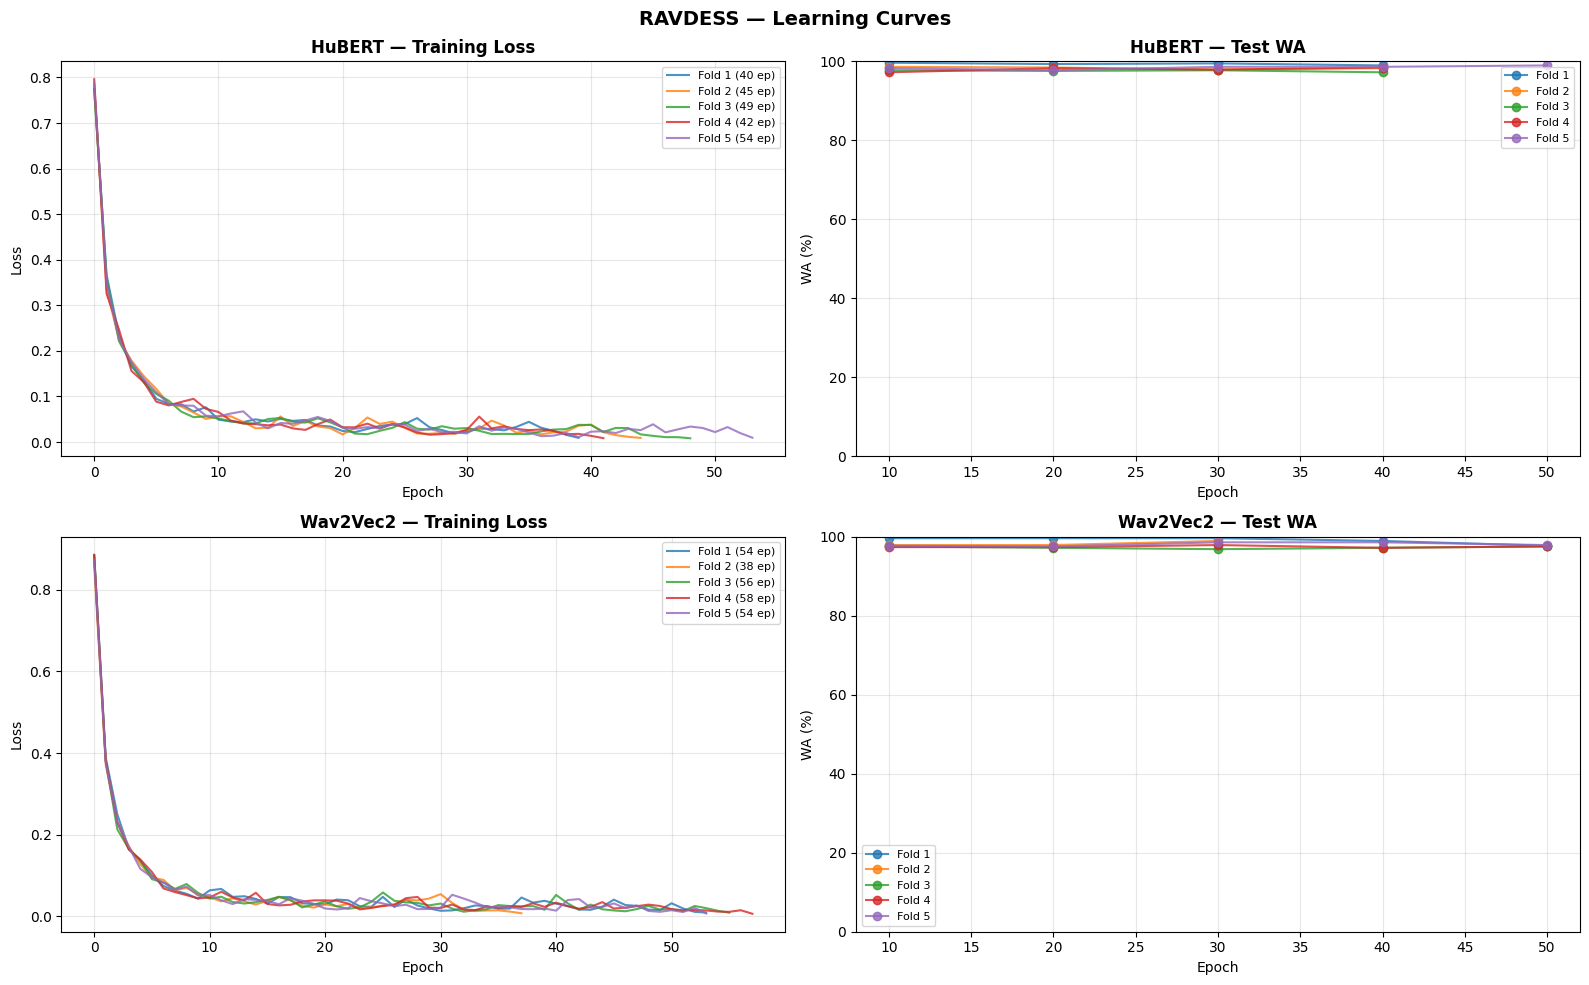

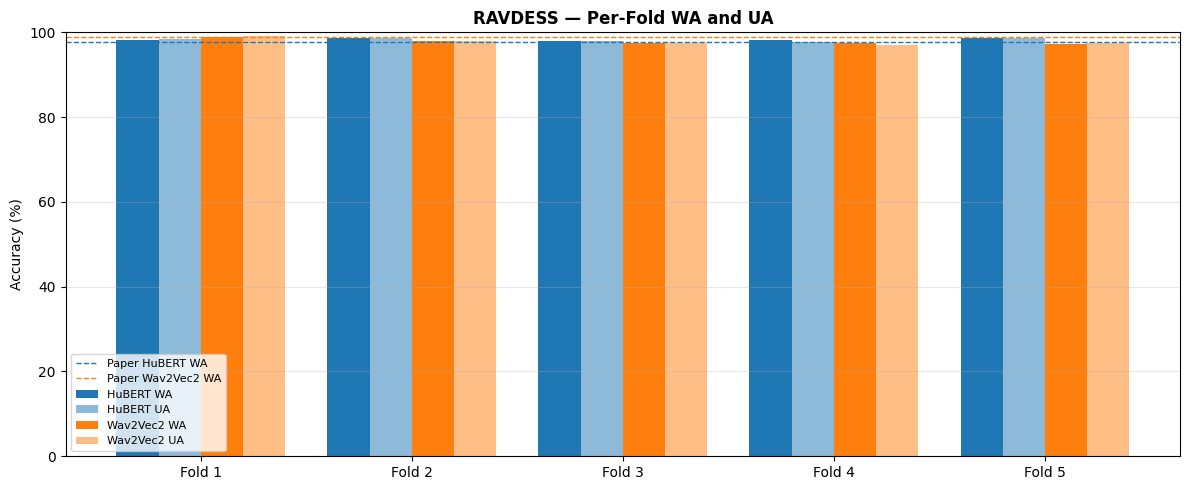

Performance charts saved


In [17]:
def plot_learning_curves(results, ax_loss, ax_wa):
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for i, h in enumerate(results['history']):
        ax_loss.plot(h['losses'], color=colors[i], alpha=0.8,
                     label=f"Fold {h['fold']} ({h['epochs']} ep)")
        wa_epochs = [(e+1)*10 for e in range(len(h['was']))]
        ax_wa.plot(wa_epochs, h['was'], color=colors[i], marker='o',
                   alpha=0.8, label=f"Fold {h['fold']}")
    ax_loss.set_title(f"{results['model_name']} — Training Loss", fontweight='bold')
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)
    ax_wa.set_title(f"{results['model_name']} — Test WA", fontweight='bold')
    ax_wa.set_xlabel("Epoch"); ax_wa.set_ylabel("WA (%)")
    ax_wa.set_ylim(0, 100); ax_wa.legend(fontsize=8); ax_wa.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_learning_curves(results_hubert,  axes[0][0], axes[0][1])
plot_learning_curves(results_wav2vec, axes[1][0], axes[1][1])
plt.suptitle(f"RAVDESS — Learning Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
x, width = np.arange(N_FOLDS), 0.2
ax.bar(x-width*1.5, results_hubert['fold_wa'],  width, label='HuBERT WA',   color='#1f77b4')
ax.bar(x-width*0.5, results_hubert['fold_ua'],  width, label='HuBERT UA',   color='#1f77b4', alpha=0.5)
ax.bar(x+width*0.5, results_wav2vec['fold_wa'], width, label='Wav2Vec2 WA', color='#ff7f0e')
ax.bar(x+width*1.5, results_wav2vec['fold_ua'], width, label='Wav2Vec2 UA', color='#ff7f0e', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i+1}" for i in range(N_FOLDS)])
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title(f"RAVDESS — Per-Fold WA and UA", fontweight='bold')
ax.axhline(97.83, color='#1f77b4', linestyle='--', linewidth=1, label='Paper HuBERT WA')
ax.axhline(99.00, color='#ff7f0e', linestyle='--', linewidth=1, label='Paper Wav2Vec2 WA')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}ser_{DATASET_NAME.lower()}_per_fold_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Performance charts saved")